In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import seaborn as sns
import statsmodels.api as sm

data_url = "https://docs.google.com/spreadsheets/d/1KlAuWyXWnve-y3_oQMhZCONOYDIF2ToCLzd4sg0XfPU/export?format=csv"
df=pd.read_csv(data_url)

In [ ]:
df

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,195.99,195.99,No Badge,Organic,No Coupon,NaN,2025-09-04,NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,https://www.amazon.com/Elgato-4K-Pro-Internal-...,2025-08-30 19:56:33,TV & Display,0.00
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,89.99,89.99,No Badge,Organic,Save $25.00 with coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,https://www.amazon.com/Arlo-Essential-Spotligh...,2025-08-30 19:56:33,Cameras,0.00
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,1099.99,Save 18%,Organic,No Coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,https://www.amazon.com/GIGABYTE-FO32U2-32-3840...,2025-08-30 19:56:33,Chargers & Cables,18.18
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,No Badge,Organic,No Coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,https://www.amazon.com/Monoprice-XLR-Male-4-In...,2025-08-30 19:56:33,Chargers & Cables,34.98


In [ ]:
pd.unique(df['is_best_seller'])

array(['No Badge', 'Best Seller', "Amazon's", 'Limited time deal',
       'Save 30%', 'Save 12%', 'Save 9%', 'Save 17%', 'Save 77%',
       'Ends in', 'Save 10%', 'Save 18%'], dtype=object)

In [ ]:
pd.unique(df['product_category'])

array(['Phones', 'Laptops', 'Other Electronics', 'Cameras', 'Storage',
       'Printers & Scanners', 'TV & Display', 'Power & Batteries',
       'Chargers & Cables', 'Headphones', 'Networking', 'Speakers',
       'Wearables', 'Gaming', 'Smart Home'], dtype=object)

In [ ]:
df.columns
df = df.drop(columns = ['product_image_url', 'product_page_url', 'data_collected_at', 'delivery_date', 'sustainability_tags'])

In [ ]:
sample = df

sample = sample.drop(columns = ['discounted_price', 'original_price', 'buy_box_availability'])

sample

,product_title,product_rating,total_reviews,purchased_last_month,is_best_seller,is_sponsored,has_coupon,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,No Badge,Sponsored,Save 15% with coupon,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,No Badge,Sponsored,No Coupon,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,No Badge,Sponsored,No Coupon,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,Best Seller,Organic,No Coupon,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,No Badge,Organic,No Coupon,Phones,0.00
...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,No Badge,Organic,No Coupon,TV & Display,0.00
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,No Badge,Organic,Save $25.00 with coupon,Cameras,0.00
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,Save 18%,Organic,No Coupon,Chargers & Cables,18.18
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,No Badge,Organic,No Coupon,Chargers & Cables,34.98


In [ ]:
df

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,Phones,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,195.99,195.99,No Badge,Organic,No Coupon,NaN,TV & Display,0.00
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,89.99,89.99,No Badge,Organic,Save $25.00 with coupon,Add to cart,Cameras,0.00
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,1099.99,Save 18%,Organic,No Coupon,Add to cart,Chargers & Cables,18.18
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,No Badge,Organic,No Coupon,Add to cart,Chargers & Cables,34.98


In [ ]:
def missing_values(df):
    for i in df.columns:
        print(f"{i}: {df[i].isnull().sum()}, {df[i].isnull().sum() / len(df) * 100}")
    print(df.shape)
    print(df.head())

missing_values(df)

product_title: 0, 0.0
product_rating: 1024, 2.3995313415348565
total_reviews: 1024, 2.3995313415348565
purchased_last_month: 10511, 24.630345635618042
discounted_price: 2062, 4.83186877562976
original_price: 2062, 4.83186877562976
is_best_seller: 0, 0.0
is_sponsored: 0, 0.0
has_coupon: 0, 0.0
buy_box_availability: 14653, 34.33626244874048
product_category: 0, 0.0
discount_percentage: 2062, 4.83186877562976
(42675, 12)
                                       product_title  product_rating  \
0  BOYA BOYALINK 2 Wireless Lavalier Microphone f...             4.6   
1  LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...             4.3   
2  DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...             4.6   
3  Apple AirPods Pro 2 Wireless Earbuds, Active N...             4.6   
4  Apple AirTag 4 Pack. Keep Track of and find Yo...             4.8   

   total_reviews  purchased_last_month  discounted_price  original_price  \
0          375.0                 300.0             89.68          159

In [ ]:
df = df.dropna(subset = ['product_rating', 'purchased_last_month', 'discounted_price'])
df['buy_box_availability'] = df['buy_box_availability'].fillna(False)

missing_values(df)

product_title: 0, 0.0
product_rating: 0, 0.0
total_reviews: 0, 0.0
purchased_last_month: 0, 0.0
discounted_price: 0, 0.0
original_price: 0, 0.0
is_best_seller: 0, 0.0
is_sponsored: 0, 0.0
has_coupon: 0, 0.0
buy_box_availability: 0, 0.0
product_category: 0, 0.0
discount_percentage: 0, 0.0
(30228, 12)
                                       product_title  product_rating  \
0  BOYA BOYALINK 2 Wireless Lavalier Microphone f...             4.6   
1  LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...             4.3   
2  DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...             4.6   
3  Apple AirPods Pro 2 Wireless Earbuds, Active N...             4.6   
4  Apple AirTag 4 Pack. Keep Track of and find Yo...             4.8   

   total_reviews  purchased_last_month  discounted_price  original_price  \
0          375.0                 300.0             89.68          159.00   
1         2457.0                6000.0              9.99           15.99   
2         3044.0                2000.0

/tmp/ipython-input-1806053444.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['buy_box_availability'] = df['buy_box_availability'].fillna(False)


In [ ]:
df['badge_group'] = (df['is_best_seller'] != 'No Badge').astype(int)
df['badge_group']

/tmp/ipython-input-739550250.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['badge_group'] = (df['is_best_seller'] != 'No Badge').astype(int)


,badge_group
0,0
1,0
2,0
3,1
4,0
...,...
42670,0
42671,0
42672,1
42673,0


In [ ]:
df['has_coupon'] = df['has_coupon'].apply(lambda x: 'Coupon' if isinstance(x, str) and 'with coupon' in x.lower() else 'No Coupon')

df['is_best_seller'] = df['is_best_seller'].apply(lambda x: 'Best Seller' if isinstance(x, str) and 'best seller' in x.lower() else 'No Badge')

df = pd.get_dummies(df, columns=['is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability'], drop_first=True)

df.head()

/tmp/ipython-input-2087552405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['has_coupon'] = df['has_coupon'].apply(lambda x: 'Coupon' if isinstance(x, str) and 'with coupon' in x.lower() else 'No Coupon')
/tmp/ipython-input-2087552405.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_best_seller'] = df['is_best_seller'].apply(lambda x: 'Best Seller' if isinstance(x, str) and 'best seller' in x.lower() else 'No Badge')


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,product_category,discount_percentage,badge_group,is_best_seller_No Badge,is_sponsored_Sponsored,has_coupon_No Coupon,buy_box_availability_Add to cart
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,Phones,43.60,0,True,True,False,True
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,Laptops,37.52,0,True,True,True,True
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,Laptops,10.03,0,True,True,True,True
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Phones,0.00,1,False,False,True,False
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,Phones,0.00,0,True,False,True,False


In [ ]:
df.columns

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'discounted_price', 'original_price',
       'product_category', 'discount_percentage', 'badge_group',
       'is_best_seller_No Badge', 'is_sponsored_Sponsored',
       'has_coupon_No Coupon', 'buy_box_availability_Add to cart'],
      dtype='object')

In [ ]:
# Descriptive Statistics
main_vars = ["product_rating", "purchased_last_month"]
cols = main_vars

stats = pd.DataFrame({
    "count":  df[cols].count(),
    "mean":   df[cols].mean(numeric_only=True),
    "median": df[cols].median(numeric_only=True),
    "std":    df[cols].std(numeric_only=True, ddof=1),
    "min":    df[cols].min(numeric_only=True),
    "max":    df[cols].max(numeric_only=True),
    "nan_count":    df[cols].isna().sum(),
}).round(3)

In [ ]:
stats

,count,mean,median,std,min,max,nan_count
product_rating,30228,4.439,4.5,0.359,2.0,5.0,0
purchased_last_month,30228,1354.570,200.0,6476.654,50.0,100000.0,0


From the statistics of the two variables we can find interesting insights:

1. We have more ratings than purchases. This is due to the fact that a lot of products were not bought last month but still have a rating from past purchases. We can see it from the number of nan_counts.

2. In stars the median is 4.5 and the mean is 4.399. The mean being lower is because of products with super low ratings. With purchased_last_month, the median is 200 and the mean is 1293.665. The mean is higher because there are products with a high numbers of purchases in the last month.

3. We also have products that have no rating.

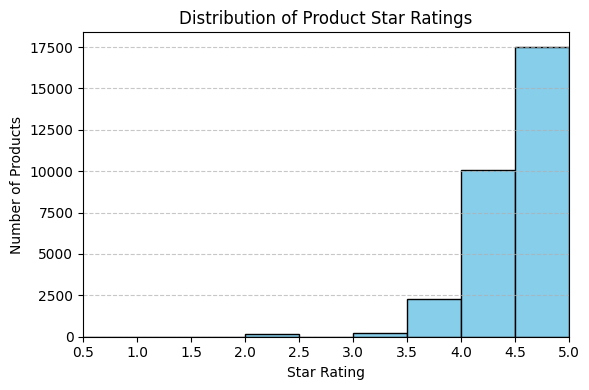

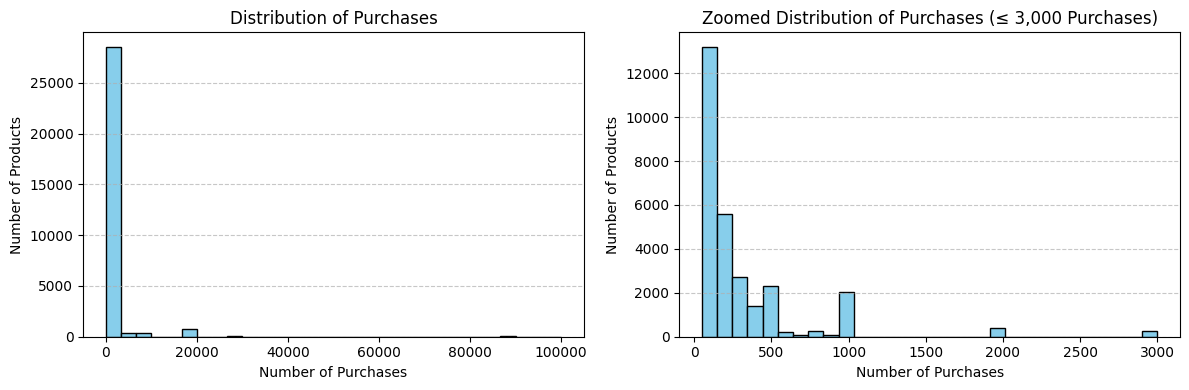

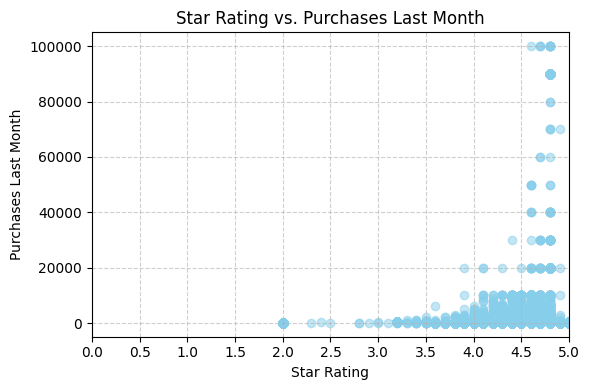

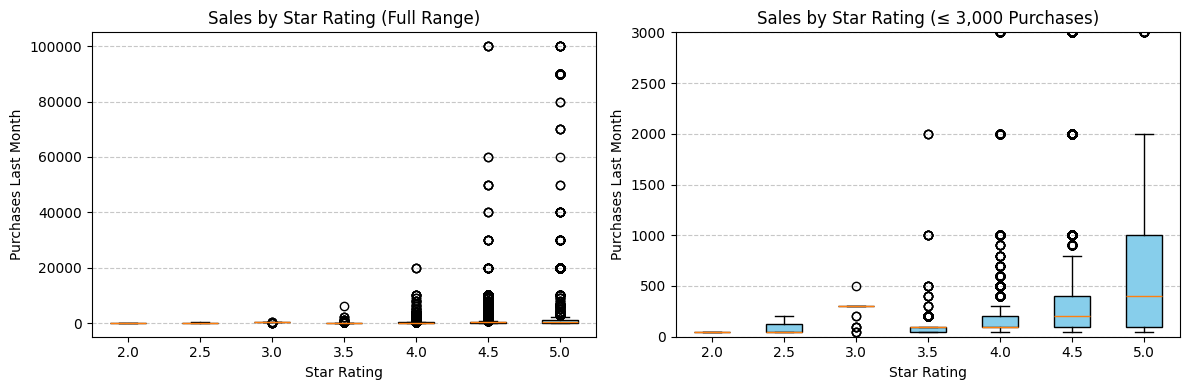

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# keep only needed cols, drop missing, ensure numeric
df_plot = df[['product_rating','purchased_last_month']].copy()
df_plot = df_plot.dropna()
df_plot['product_rating'] = pd.to_numeric(df_plot['product_rating'], errors='coerce')
df_plot['purchased_last_month'] = pd.to_numeric(df_plot['purchased_last_month'], errors='coerce')
df_plot = df_plot.dropna()

# ====================================================
# Histogram: Distribution of Star Ratings
# ====================================================
plt.figure(figsize=(6,4))

# Define bins up to 5.0 only
bins = np.arange(0.5, 5.1, 0.5)

plt.hist(df["product_rating"], bins=bins, color='skyblue', edgecolor='black')

plt.title('Distribution of Product Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set ticks only up to 5.0
plt.xticks(np.arange(0.5, 5.1, 0.5))
plt.xlim(0.5, 5.0)

plt.tight_layout()
plt.show()

# ====================================================
# Histogram: Distribution of Sales (Purchases Last Month)
# ====================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: Full distribution ---
axes[0].hist(df_plot['purchased_last_month'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Purchases')
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Number of Products')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Right: Capped distribution (≤ 3000) ---
axes[1].hist(df_plot.loc[df_plot['purchased_last_month'] <= 3000, 'purchased_last_month'],
             bins=30, color='skyblue', edgecolor='black')
axes[1].set_title('Zoomed Distribution of Purchases (≤ 3,000 Purchases)')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Products')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



# ====================================================
# Scatterplot: Star Rating vs. Sales
# ====================================================
plt.figure(figsize=(6,4))
plt.scatter(df_plot['product_rating'], df_plot['purchased_last_month'], alpha=0.5, color='skyblue')
plt.title('Star Rating vs. Purchases Last Month')
plt.xlabel('Star Rating')
plt.ylabel('Purchases Last Month')
plt.grid(True, linestyle='--', alpha=0.6)

# Set x-axis from 0.0 to 5.0, with ticks every 0.5
plt.xlim(0, 5.0)
plt.xticks(np.arange(0, 5.1, 0.5))

plt.tight_layout()
plt.show()
import numpy as np
import matplotlib.pyplot as plt

# Group to nearest 0.5-star instead of integer
df_plot['rating_group'] = (df_plot['product_rating'] * 2).round() / 2
df_plot['rating_group'] = df_plot['rating_group'].clip(1, 5)

# Define the 0.5-step groups
groups = np.arange(1.0, 5.1, 0.5)  # 1.0, 1.5, ..., 5.0

# Build data + labels (skip empty groups to avoid empty boxes)
data = [df_plot.loc[df_plot['rating_group'] == g, 'purchased_last_month'] for g in groups]
labels = [str(g) for g, s in zip(groups, data) if not s.empty]
data   = [s for s in data if not s.empty]



# ====================================================
# Side-by-side boxplots
# ====================================================
# Note: since we already know in our data, no orders have ratings below 2
# so that's why our boxplot's x-axis automatically starts from 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Full range
b1 = axes[0].boxplot(data, patch_artist=True)
for patch in b1['boxes']:
    patch.set(facecolor='skyblue', edgecolor='black')
axes[0].set_title('Sales by Star Rating (Full Range)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Purchases Last Month')
axes[0].set_xticklabels(labels)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Right: Zoomed (≤ 3,000)
b2 = axes[1].boxplot(data, patch_artist=True)
for patch in b2['boxes']:
    patch.set(facecolor='skyblue', edgecolor='black')
axes[1].set_ylim(0, 3000)
axes[1].set_title('Sales by Star Rating (≤ 3,000 Purchases)')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Purchases Last Month')
axes[1].set_xticklabels(labels)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Insights for our x and y variables:

The distribution of rating is left-skewed. Majority of the ratings are between 4.0 inclusive and 5.0 exclusive. The mode is 4.5.

The distribution of sales is right-skewed. Majority of the products have been bought less than 500 times in the past month.

In the start rating vs purchases in the last month, we see that there is a weak positive correlation between both variables.

In the box plots we can see that the number of outliers increases as the star rating increases. Same happens with the variability of the star rating.

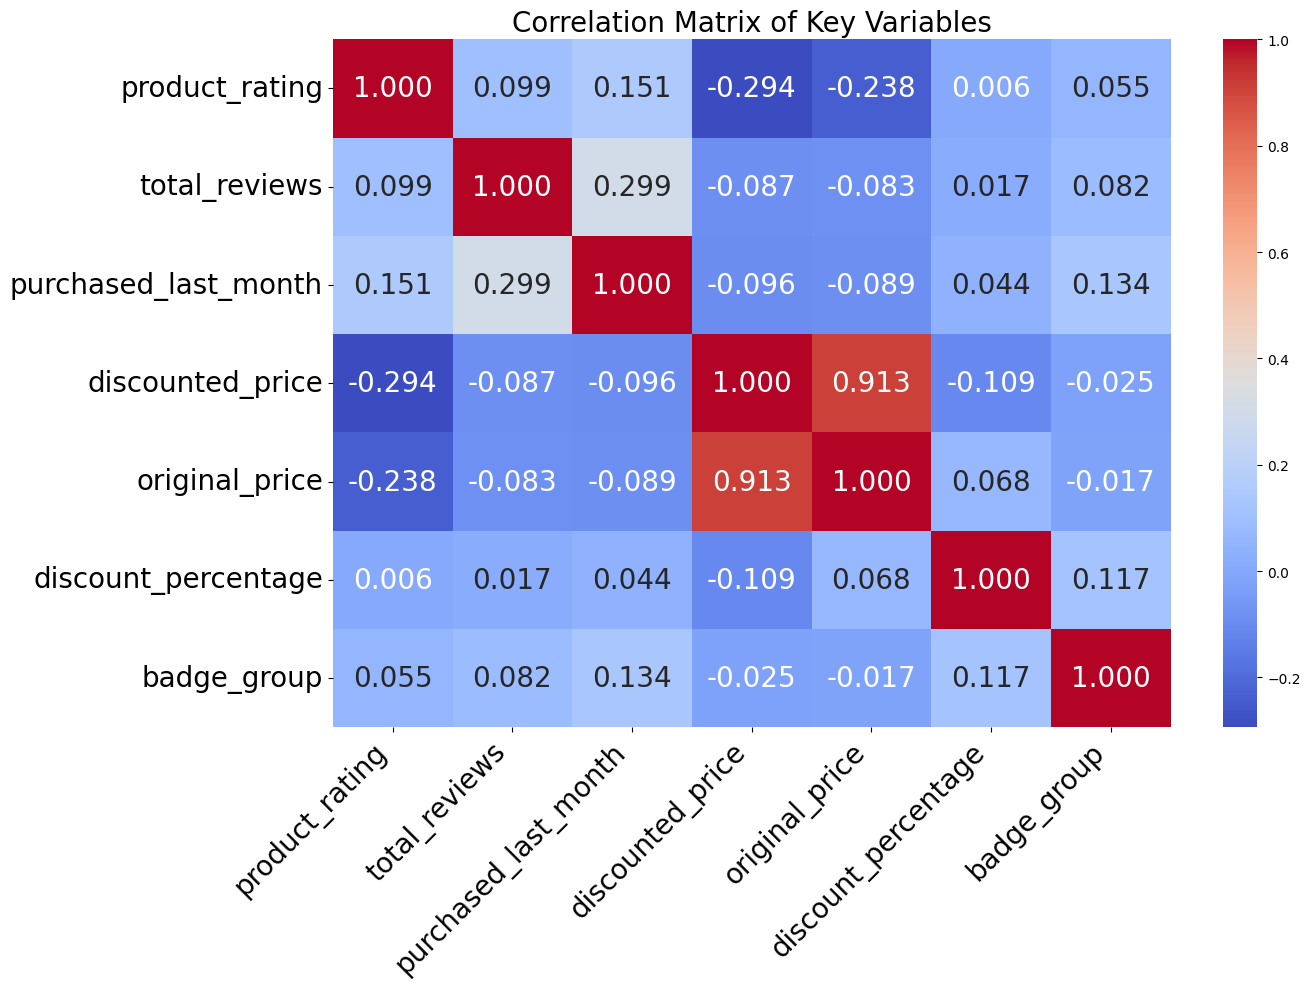

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,badge_group
product_rating,1.000000,0.099372,0.151390,-0.294041,-0.238463,0.006486,0.055282
total_reviews,0.099372,1.000000,0.299240,-0.087026,-0.083030,0.016975,0.082394
purchased_last_month,0.151390,0.299240,1.000000,-0.095771,-0.089010,0.044170,0.134451
discounted_price,-0.294041,-0.087026,-0.095771,1.000000,0.913084,-0.108510,-0.025393
original_price,-0.238463,-0.083030,-0.089010,0.913084,1.000000,0.068095,-0.017453
discount_percentage,0.006486,0.016975,0.044170,-0.108510,0.068095,1.000000,0.117411
badge_group,0.055282,0.082394,0.134451,-0.025393,-0.017453,0.117411,1.000000


In [ ]:
# Correlation Matrix & correlation coefficient r (scale and strength)
corr_vars = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = corr_vars.corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f",annot_kws={"size": 20})
plt.title("Correlation Matrix of Key Variables", fontsize=20)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20, rotation=0)
plt.tight_layout()
plt.show()

corr_matrix

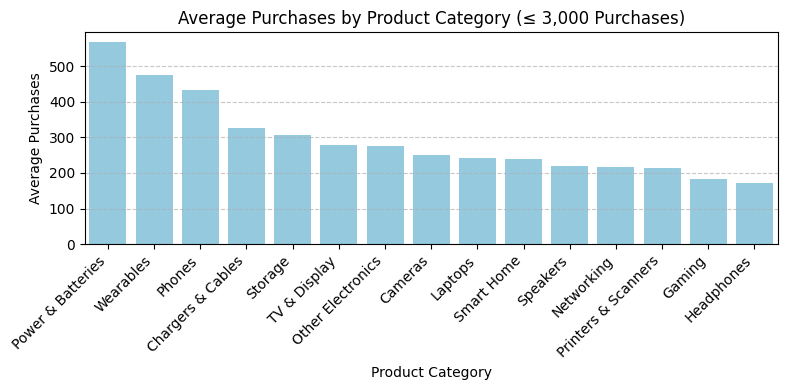

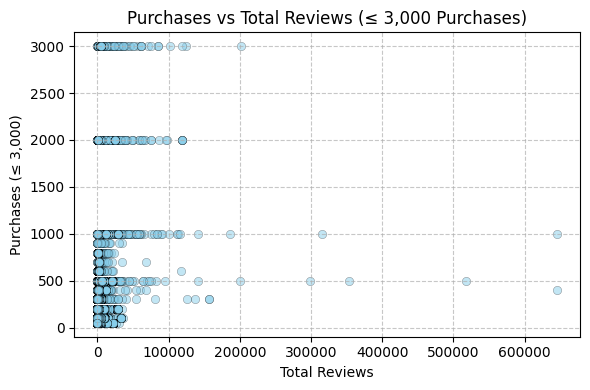

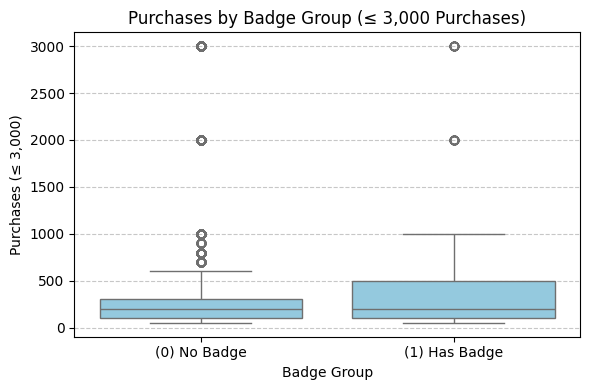

In [ ]:
## Confounding Variable Plots

# ====================================================
## product_category vs purchased_last_month
## total_reviews vs purchased_last_month
## is_best_seller vs purchased_last_month
# ====================================================

import seaborn as sns
import pandas as pd

df_conf = df.copy()

# --- Keep only purchases ≤ 3000 for clarity ---
df_conf = df_conf[df_conf['purchased_last_month'] <= 3000]

# --- Define color palette ---
color = 'skyblue'

# ======================================================
# Product Category vs Purchases
# ======================================================
plt.figure(figsize=(8,4))

# Compute average purchases by category
avg_purchases = (
    df_conf.groupby('product_category')['purchased_last_month']
    .mean()
    .sort_values(ascending=False)
)

# Bar plot for average purchases
sns.barplot(
    x=avg_purchases.index,
    y=avg_purchases.values,
    color=color
)

plt.title('Average Purchases by Product Category (≤ 3,000 Purchases)')
plt.xlabel('Product Category')
plt.ylabel('Average Purchases')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ======================================================
# Total Reviews vs Purchases
# ======================================================
plt.figure(figsize=(6,4))

# Scatterplot showing relationship between reviews and purchases
sns.scatterplot(
    x='total_reviews',
    y='purchased_last_month',
    data=df_conf,
    color=color,
    alpha=0.5,
    edgecolor='black',
    linewidth=0.3
)

plt.title('Purchases vs Total Reviews (≤ 3,000 Purchases)')
plt.xlabel('Total Reviews')
plt.ylabel('Purchases (≤ 3,000)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ======================================================
# Badge Group vs Purchases
# ======================================================
plt.figure(figsize=(6, 4))

sns.boxplot(
    x='badge_group',
    y='purchased_last_month',
    data=df_conf,
    color=color
)

plt.title('Purchases by Badge Group (≤ 3,000 Purchases)')
plt.xlabel('Badge Group')
plt.ylabel('Purchases (≤ 3,000)')
plt.xticks([0, 1], ['(0) No Badge', '(1) Has Badge'])  # label 0/1 nicely
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Our three confounding varibales
&
Why they may be considered as confounding var here in our case:

1. Product Category – Different categories attract different levels of consumer demand; certain types (like electronics or toys) naturally sell more, making category a potential confounding factor affecting both rating and sales.

2. Total Reviews - Products with more reviews often appear more trustworthy or popular, which can increase sales while also correlating with higher ratings, creating overlap in influence.

3. Badge (No Badge, Best Seller, Amazon's Choice, Discount Badge) – Official badges like Best Seller signal product quality and popularity, directly boosting purchases and potentially influencing ratings, thus confounding the relationship between ratings and sales.

In [ ]:
df = pd.get_dummies(df, columns=['product_category'], drop_first=True)

In [ ]:
X_num = df.select_dtypes(include=[float, int])
X_num = X_num.drop(columns=['product_rating'])
X_num = add_constant(X_num)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]

print(vif_data)

                Feature       VIF
0                 const  1.983264
1         total_reviews  1.104747
2  purchased_last_month  1.119597
3      discounted_price  7.310382
4        original_price  7.258401
5   discount_percentage  1.237907
6           badge_group  1.034763


In [ ]:
df.columns

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'discounted_price', 'original_price',
       'discount_percentage', 'badge_group', 'is_best_seller_No Badge',
       'is_sponsored_Sponsored', 'has_coupon_No Coupon',
       'buy_box_availability_Add to cart',
       'product_category_Chargers & Cables', 'product_category_Gaming',
       'product_category_Headphones', 'product_category_Laptops',
       'product_category_Networking', 'product_category_Other Electronics',
       'product_category_Phones', 'product_category_Power & Batteries',
       'product_category_Printers & Scanners', 'product_category_Smart Home',
       'product_category_Speakers', 'product_category_Storage',
       'product_category_TV & Display', 'product_category_Wearables'],
      dtype='object')

                             OLS Regression Results                             
Dep. Variable:     purchased_last_month   R-squared:                       0.023
Model:                              OLS   Adj. R-squared:                  0.023
Method:                   Least Squares   F-statistic:                     709.0
Date:                  Tue, 02 Dec 2025   Prob (F-statistic):          2.00e-154
Time:                          08:36:02   Log-Likelihood:            -3.0782e+05
No. Observations:                 30228   AIC:                         6.156e+05
Df Residuals:                     30226   BIC:                         6.157e+05
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1.077e+0

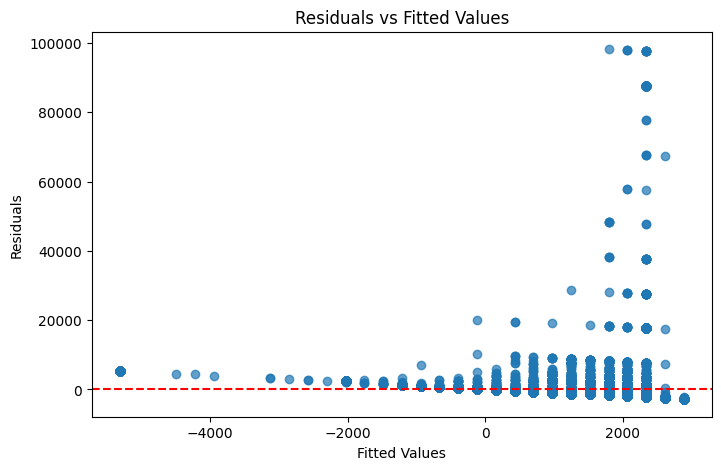

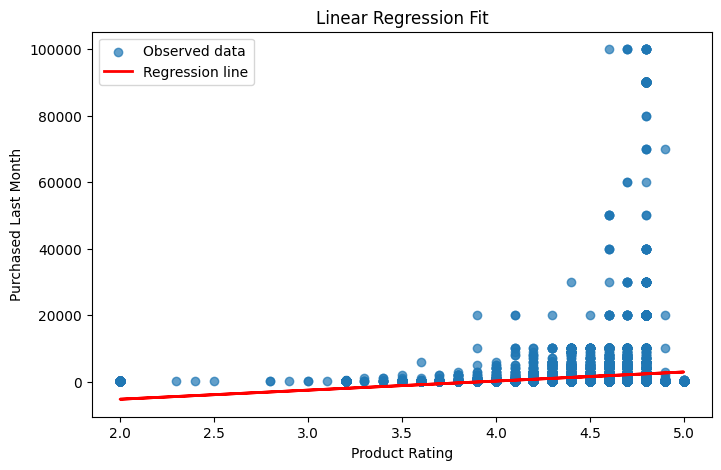

In [ ]:
iX = df[['product_rating']]

y = df['purchased_last_month']

for col in iX.select_dtypes(include='bool').columns:
    iX[col] = iX[col].astype(int)

X = sm.add_constant(iX)

model = sm.OLS(y, X).fit()

print(model.summary())

rmse = np.sqrt(((model.resid) ** 2).mean())
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(model.fittedvalues, model.resid, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(iX['product_rating'], y, alpha=0.7, label="Observed data")
plt.plot(iX['product_rating'], model.fittedvalues, color='red', linewidth=2, label="Regression line")
plt.xlabel("Product Rating")
plt.ylabel("Purchased Last Month")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

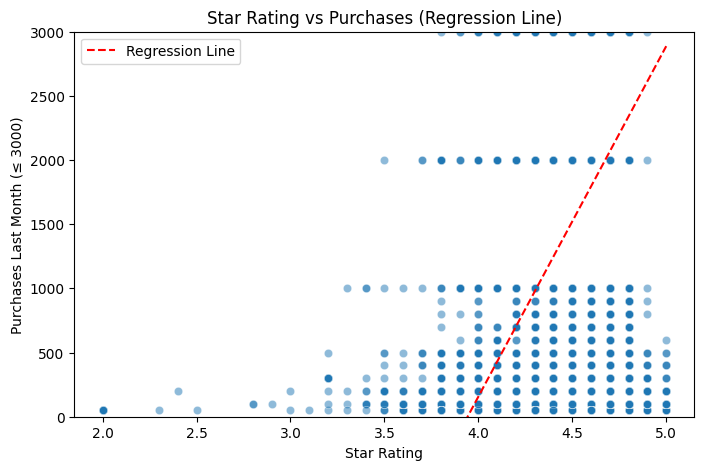

In [ ]:
# Filter purchases <= 3000 for visualization
df_plot = df[df['purchased_last_month'] <= 3000]

# Prepare data for regression
X = sm.add_constant(df['product_rating'])
y = df['purchased_last_month']
model = sm.OLS(y, X).fit()

# Predictions for regression line
pred_x = np.linspace(df['product_rating'].min(), df['product_rating'].max(), 100)
pred_X = sm.add_constant(pred_x)
pred_y = model.predict(pred_X)

# Plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_plot,
    x='product_rating',
    y='purchased_last_month',
    alpha=0.5
)

# Regression line
plt.plot(pred_x, pred_y, color='red', linestyle='--', label='Regression Line')

# Limit y-axis to <= 3000 to zoom in and see the trend
plt.ylim(0, 3000)

plt.xlabel("Star Rating")
plt.ylabel("Purchases Last Month (≤ 3000)")
plt.title("Star Rating vs Purchases (Regression Line)")
plt.legend()
plt.show()


In [ ]:
df['int_pr_tr'] = df['product_rating'] * df['total_reviews']
df['int_pr_dp'] = df['product_rating'] * df['discount_percentage']
df['int_pr_br'] = df['product_rating'] * df['badge_group']
df['int_pr_s'] = df['product_rating'] * df['is_sponsored_Sponsored']
df['int_pr_c'] = df['product_rating'] * df['has_coupon_No Coupon']

/tmp/ipython-input-4164450823.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iX[col] = iX[col].astype(int)
/tmp/ipython-input-4164450823.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iX[col] = iX[col].astype(int)
/tmp/ipython-input-4164450823.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexi

                             OLS Regression Results                             
Dep. Variable:     purchased_last_month   R-squared:                       0.307
Model:                              OLS   Adj. R-squared:                  0.307
Method:                   Least Squares   F-statistic:                     638.5
Date:                  Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                          08:33:41   Log-Likelihood:            -3.0262e+05
No. Observations:                 30228   AIC:                         6.053e+05
Df Residuals:                     30206   BIC:                         6.055e+05
Df Model:                            21                                         
Covariance Type:              nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

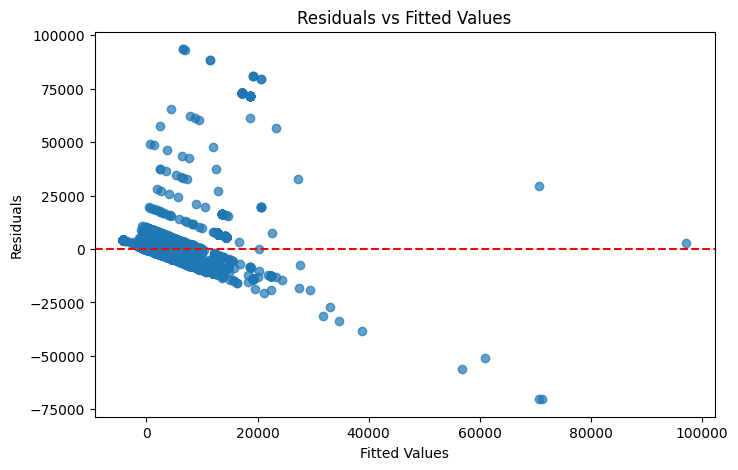

In [ ]:
iX = df[['product_rating', 'discount_percentage', 'total_reviews', 'int_pr_s', 'badge_group', 'is_sponsored_Sponsored', 'has_coupon_No Coupon',
       'product_category_Chargers & Cables', 'product_category_Gaming',
       'product_category_Headphones', 'product_category_Laptops',
       'product_category_Networking', 'product_category_Other Electronics',
       'product_category_Phones', 'product_category_Power & Batteries',
       'product_category_Printers & Scanners', 'product_category_Smart Home',
       'product_category_Speakers', 'product_category_Storage',
       'product_category_TV & Display', 'product_category_Wearables']]

y = df['purchased_last_month']

for col in iX.select_dtypes(include='bool').columns:
    iX[col] = iX[col].astype(int)

X = sm.add_constant(iX)

model = sm.OLS(y, X).fit()

print(model.summary())

rmse = np.sqrt(((model.resid) ** 2).mean())
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(model.fittedvalues, model.resid, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()